### Goal
Obatins the linear gain (G) and compare the linear output expected with the real output

#### 1. Setup

In [1]:
# Importing packages
import numpy as np
import pandas as pd

from pa_model.dataset import Dataset
from pa_model.paths import DATA_RAW, DATA_PROCESSED

from pathlib import Path
import matplotlib.pyplot as plt

#### 2. Functions

In [2]:
EPS = 1e-15

def to_decibel(v):
    """complexo -> magnitude em dB"""
    return 20 * np.log10(np.abs(v) + EPS)

In [3]:
# Ploting the AM/AM signal
def plot_AM_AM(x, y, db=True, title="AM/AM Graph"):
    fig, ax = plt.subplots(figsize=(10, 5))
    if db:
        ax.plot(to_decibel(x), to_decibel(y), '.', ms=3, alpha=.3)
        ax.set_xlabel("|x| (dB)"); ax.set_ylabel("|y| (dB)")
    else:
        ax.plot(np.abs(x), np.abs(y), '.', ms=3, alpha=.3)
        ax.set_xlabel("|x|"); ax.set_ylabel("|y|")
    ax.set_title(title); ax.grid(True, alpha=.3)
    plt.show()

#### 3. Loading, Filtering and Ploting Data

In [4]:
# Loading Dataset
path_initial_data = f"{DATA_RAW}/dadosIniciais.csv"
path_experiment_data = f"{DATA_PROCESSED}/expData.csv"

if Path(path_experiment_data).exists():
    ds = Dataset.from_csv(path_experiment_data)
else:
    df = pd.read_csv(path_initial_data)
    df = df.loc[df.index.repeat(10)].reset_index(drop=True)
    df = df.sample(frac=1,random_state=42).reset_index(drop=True)
    df.to_csv(path_experiment_data,index=False)
    ds = Dataset.from_csv(path_experiment_data)

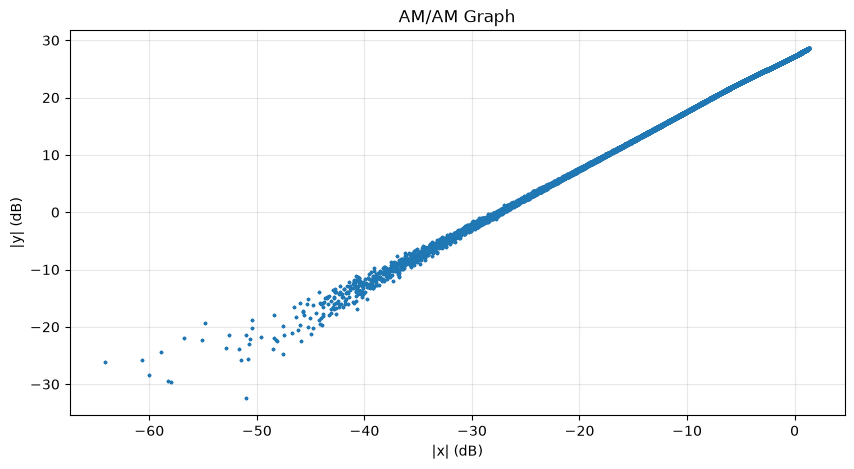

In [5]:
# Ploting AM/AM
plot_AM_AM(ds.x, ds.y)

In [6]:
# Filtering Dataset to get only the values with linear relation
x_db = to_decibel(ds.x)
mask = (x_db > -20) & (x_db < 0)
filtered_x, filtered_y = ds.x[mask], ds.y[mask]

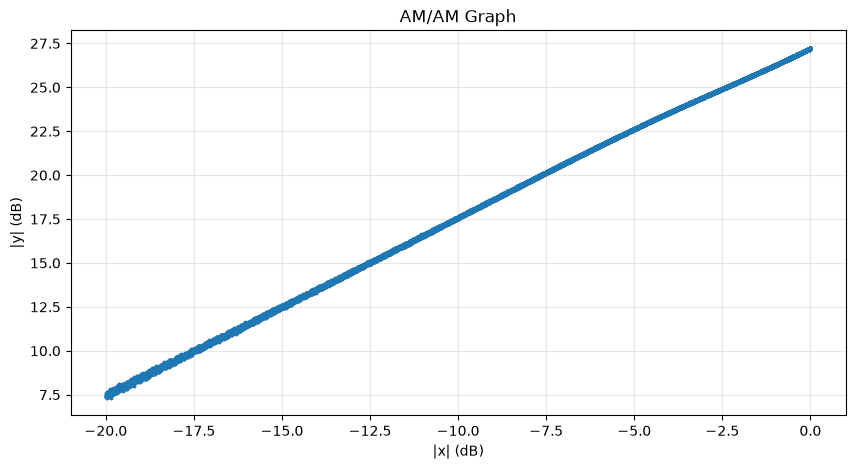

In [7]:
# Ploting Filtered Data
plot_AM_AM(filtered_x,filtered_y)

#### 4. Calculating the Gain

In [8]:
# Calculate the Linear Gain
def get_linear_gain(x,y):
    xi, xq = x.real, x.imag
    yi, yq = y.real, y.imag

    den = np.sum(xi**2 + xq**2)
    gi = np.sum(yi*xi + yq*xq)/den
    gq = np.sum(yq*xi - yi*xq)/den

    return gi, gq

In [9]:
# Calculate the linear output
def get_linear_output(x, gi, gq):
    xi, xq = x.real, x.imag

    yi_lin = gi*xi - gq*xq
    yq_lin = gi*xq + gq*xi

    return yi_lin, yq_lin

In [ ]:
# Getting linear gain and output
X, Y = filtered_x, filtered_y
gi, gq = get_linear_gain(X,Y)
Y_lini, Y_linq = get_linear_output(X,gi,gq)

print(f"Gi:{gi:.2f}, Gq:{gq:.2f}")

#### 5. Comparing the Real Output with the Linear Output

In [ ]:
# Comparing the real output with the expected linear output
def plot_real_vs_linear(y, y_lini, y_linq, title="Real vs Linear Output"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)

    # I and Q against the ideal linear response
    for ax, real, lin, name in ((axes[0], y.real, y_lini, "I"),
                                (axes[1], y.imag, y_linq, "Q")):
        lo, hi = min(lin.min(), real.min()), max(lin.max(), real.max())
        ax.plot(lin, real, '.', ms=2, alpha=.2, color="#2a78d6", rasterized=True)
        ax.plot([lo, hi], [lo, hi], '-', color="#898781", lw=1.5, label="ideal linear")
        ax.set_xlabel(f"$Y_{{lin,{name}}}$"); ax.set_ylabel(f"$Y_{{real,{name}}}$")
        ax.set_title(f"{name} component"); ax.set_aspect('equal', 'box')
        ax.grid(True, alpha=.3); ax.set_axisbelow(True)
        ax.legend(frameon=False, loc="upper left")

    fig.suptitle(title)
    plt.show()

In [ ]:
# Gain deviation: how far the real gain sits from the fitted linear gain, per input level
def plot_gain_deviation(x, y, y_lini, y_linq, title="Gain Deviation"):
    x_db = to_decibel(x)
    dev = to_decibel(y) - to_decibel(y_lini + 1j*y_linq)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axhline(0, color="#898781", lw=1.5, label="ideal linear")
    ax.plot(x_db, dev, '.', ms=2, alpha=.2, color="#2a78d6", rasterized=True)
    ax.set_xlabel("|x| (dB)"); ax.set_ylabel(r"$|Y_{real}| - |Y_{lin}|$ (dB)")
    ax.set_xlim(np.percentile(x_db, .1), x_db.max() + 1)
    ax.set_title(title); ax.grid(True, alpha=.3); ax.set_axisbelow(True)
    ax.legend(frameon=False, loc="upper left")
    plt.show()

In [ ]:
# Ploting the comparison
print(f"G = {gi:.4f} + j{gq:.4f}  ->  |G| = {to_decibel(gi + 1j*gq):.2f} dB, "
      f"angle = {np.degrees(np.angle(gi + 1j*gq)):.2f} deg")

plot_real_vs_linear(Y, Y_lini, Y_linq)
plot_gain_deviation(X, Y, Y_lini, Y_linq)